In [1]:
!git clone -b dev https://github.com/rafaelTamm/NLE-Project-Spoiler-Detection.git
%cd NLE-Project-Spoiler-Detection

Cloning into 'NLE-Project-Spoiler-Detection'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 85 (delta 33), reused 31 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 31.55 MiB | 11.39 MiB/s, done.
Resolving deltas: 100% (33/33), done.
Updating files: 100% (25/25), done.
/content/NLE-Project-Spoiler-Detection


In [2]:
from pathlib import Path

print("Current directory:", Path.cwd())

print("\nFiles in results/:")
results_dir = Path("results")

if results_dir.exists():
    for path in sorted(results_dir.iterdir()):
        print(" -", path.name)
else:
    print("results/ directory does not exist")

print("\nAll CSV files in repository:")
for path in sorted(Path(".").rglob("*.csv")):
    print(" -", path)

Current directory: /content/NLE-Project-Spoiler-Detection

Files in results/:
 - README.md
 - modernbert_confidence.csv
 - modernbert_length_analysis.csv
 - modernbert_results.csv

All CSV files in repository:
 - data/goodreads_spoiler_20000.csv
 - data/goodreads_test.csv
 - data/goodreads_train.csv
 - data/goodreads_val.csv
 - data/imdb_spoiler_20000.csv
 - data/imdb_test.csv
 - data/imdb_train.csv
 - data/imdb_val.csv
 - results/modernbert_confidence.csv
 - results/modernbert_length_analysis.csv
 - results/modernbert_results.csv


In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
from pathlib import Path

multi_dir = Path("/content/drive/MyDrive/NLP_Spoiler_Project/multiseed")

for p in sorted(multi_dir.glob("*.csv")):
    print(p.name)

goodreads_seed_123_results.csv
goodreads_seed_456_results.csv
imdb_seed_123_results.csv
imdb_seed_456_results.csv
modernbert_multiseed_results.csv
modernbert_multiseed_summary.csv


In [5]:
import shutil
from pathlib import Path

multi_dir = Path("/content/drive/MyDrive/NLP_Spoiler_Project/multiseed")
results_dir = Path("/content/NLE-Project-Spoiler-Detection/results")

shutil.copy(
    multi_dir / "modernbert_multiseed_results.csv",
    results_dir / "modernbert_multiseed_results.csv"
)

shutil.copy(
    multi_dir / "modernbert_multiseed_summary.csv",
    results_dir / "modernbert_multiseed_summary.csv"
)

print("Copied:")
print(results_dir / "modernbert_multiseed_results.csv")
print(results_dir / "modernbert_multiseed_summary.csv")

Copied:
/content/NLE-Project-Spoiler-Detection/results/modernbert_multiseed_results.csv
/content/NLE-Project-Spoiler-Detection/results/modernbert_multiseed_summary.csv


In [6]:
import pandas as pd

multi = pd.read_csv(results_dir / "modernbert_multiseed_results.csv")

print("Rows:", len(multi))
print("Seeds:", sorted(multi["Seed"].unique()))
print("\nResults per experiment:")
print(multi.groupby("Experiment")["Seed"].count())

Rows: 12
Seeds: [np.int64(42), np.int64(123), np.int64(456)]

Results per experiment:
Experiment
Goodreads → Goodreads    3
Goodreads → IMDb         3
IMDb → Goodreads         3
IMDb → IMDb              3
Name: Seed, dtype: int64


In [7]:
from pathlib import Path

drive_root = Path("/content/drive/MyDrive")

wanted = {
    "tfidf_results.csv",
    "modernbert_cross_domain_error_sample.csv",
}

found = []

for path in drive_root.rglob("*.csv"):
    if path.name in wanted:
        found.append(path)

if found:
    print("Found:")
    for path in found:
        print(path)
else:
    print("Neither file was found in Google Drive.")

Found:
/content/drive/MyDrive/NLP_Spoiler_Project/results/tfidf_results.csv
/content/drive/MyDrive/NLP_Spoiler_Project/results/modernbert_cross_domain_error_sample.csv


# Final Results and Analysis

This notebook combines the final results of the TF-IDF + Logistic Regression baseline and ModernBERT.

The main ModernBERT results are aggregated across three fine-tuning seeds (42, 123, and 456) and are reported as mean ± sample standard deviation.

Detailed prediction-level analyses use the seed-42 ModernBERT models as representative runs. The truncation analysis is independent of the training seed.

Macro F1 is the primary evaluation metric.

No models are trained in this notebook.

## 1. Setup and result files

The notebook loads exported experiment results only. The multi-seed file contains the four train-test configurations for each of the three ModernBERT fine-tuning seeds.

In [8]:
from google.colab import drive
from pathlib import Path
import shutil

drive.mount("/content/drive")

repo_results = Path(
    "/content/NLE-Project-Spoiler-Detection/results"
)

drive_results = Path(
    "/content/drive/MyDrive/NLP_Spoiler_Project/results"
)

drive_multiseed = Path(
    "/content/drive/MyDrive/NLP_Spoiler_Project/multiseed"
)

files_to_copy = [
    (
        drive_results / "tfidf_results.csv",
        repo_results / "tfidf_results.csv"
    ),
    (
        drive_results / "modernbert_cross_domain_error_sample.csv",
        repo_results / "modernbert_cross_domain_error_sample.csv"
    ),
    (
        drive_multiseed / "modernbert_multiseed_results.csv",
        repo_results / "modernbert_multiseed_results.csv"
    ),
    (
        drive_multiseed / "modernbert_multiseed_summary.csv",
        repo_results / "modernbert_multiseed_summary.csv"
    ),
]

for src, dst in files_to_copy:
    shutil.copy2(src, dst)
    print("Copied:", dst.name)

print("\nCurrent results/:")
for p in sorted(repo_results.glob("*.csv")):
    print(" -", p.name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied: tfidf_results.csv
Copied: modernbert_cross_domain_error_sample.csv
Copied: modernbert_multiseed_results.csv
Copied: modernbert_multiseed_summary.csv

Current results/:
 - modernbert_confidence.csv
 - modernbert_cross_domain_error_sample.csv
 - modernbert_length_analysis.csv
 - modernbert_multiseed_results.csv
 - modernbert_multiseed_summary.csv
 - modernbert_results.csv
 - tfidf_results.csv


In [9]:
import os

os.chdir("/content/NLE-Project-Spoiler-Detection")

print("Current directory:", os.getcwd())
print("Results files:")
print(os.listdir("results"))

Current directory: /content/NLE-Project-Spoiler-Detection
Results files:
['modernbert_multiseed_results.csv', 'modernbert_multiseed_summary.csv', 'modernbert_confidence.csv', 'README.md', 'tfidf_results.csv', 'modernbert_results.csv', 'modernbert_cross_domain_error_sample.csv', 'modernbert_length_analysis.csv']


In [10]:
# Bootstrap required result files
from pathlib import Path
import os, shutil

REPO = Path("/content/NLE-Project-Spoiler-Detection")
if not REPO.exists():
    !git clone -b dev https://github.com/rafaelTamm/NLE-Project-Spoiler-Detection.git

os.chdir(REPO)
RESULTS_DIR = REPO / "results"
RESULTS_DIR.mkdir(exist_ok=True)

drive_files = {
    "tfidf_results.csv": "/content/drive/MyDrive/NLP_Spoiler_Project/results/tfidf_results.csv",
    "modernbert_cross_domain_error_sample.csv": "/content/drive/MyDrive/NLP_Spoiler_Project/results/modernbert_cross_domain_error_sample.csv",
    "modernbert_multiseed_results.csv": "/content/drive/MyDrive/NLP_Spoiler_Project/multiseed/modernbert_multiseed_results.csv",
    "modernbert_multiseed_summary.csv": "/content/drive/MyDrive/NLP_Spoiler_Project/multiseed/modernbert_multiseed_summary.csv",
}

missing = [name for name in drive_files if not (RESULTS_DIR / name).exists()]
if missing:
    from google.colab import drive
    drive.mount("/content/drive")
    for name in missing:
        src_file = Path(drive_files[name])
        if not src_file.exists():
            raise FileNotFoundError(f"Missing in Drive: {src_file}")
        shutil.copy2(src_file, RESULTS_DIR / name)
        print("Copied:", name)

print("Working directory:", Path.cwd())
print("Required result files ready.")


Working directory: /content/NLE-Project-Spoiler-Detection
Required result files ready.


In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")

TFIDF_PATH = RESULTS_DIR / "tfidf_results.csv"
MODERNBERT_MULTI_PATH = RESULTS_DIR / "modernbert_multiseed_results.csv"
CONFIDENCE_PATH = RESULTS_DIR / "modernbert_confidence.csv"
LENGTH_PATH = RESULTS_DIR / "modernbert_length_analysis.csv"
ERROR_PATH = RESULTS_DIR / "modernbert_cross_domain_error_sample.csv"

required_files = [
    TFIDF_PATH,
    MODERNBERT_MULTI_PATH,
    CONFIDENCE_PATH,
    LENGTH_PATH,
    ERROR_PATH,
]

missing = [p for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing result files:\n" + "\n".join(str(p) for p in missing)
    )

tfidf = pd.read_csv(TFIDF_PATH)
modernbert_seeds = pd.read_csv(MODERNBERT_MULTI_PATH)
confidence = pd.read_csv(CONFIDENCE_PATH)
length_results = pd.read_csv(LENGTH_PATH)
error_samples = pd.read_csv(ERROR_PATH)

print("TF-IDF rows:", len(tfidf))
print("ModernBERT rows:", len(modernbert_seeds))
print("ModernBERT seeds:", sorted(modernbert_seeds["Seed"].unique()))
display(modernbert_seeds)

TF-IDF rows: 4
ModernBERT rows: 12
ModernBERT seeds: [np.int64(42), np.int64(123), np.int64(456)]


,Model,Seed,Experiment,Accuracy,Precision,Recall,F1,Macro F1
0,ModernBERT,42,Goodreads → Goodreads,0.852789,0.851036,0.854356,0.852693,0.852789
1,ModernBERT,123,Goodreads → Goodreads,0.841115,0.844284,0.835501,0.839869,0.841106
2,ModernBERT,456,Goodreads → Goodreads,0.841764,0.851406,0.827048,0.839050,0.841719
3,ModernBERT,42,Goodreads → IMDb,0.663503,0.691111,0.577709,0.629342,0.660620
4,ModernBERT,123,Goodreads → IMDb,0.667789,0.698949,0.576471,0.631829,0.664590
5,ModernBERT,456,Goodreads → IMDb,0.661972,0.692250,0.569659,0.625000,0.658654
6,ModernBERT,42,IMDb → Goodreads,0.731193,0.694887,0.821847,0.753053,0.729070
7,ModernBERT,123,IMDb → Goodreads,0.703632,0.658376,0.843303,0.739453,0.697922
8,ModernBERT,456,IMDb → Goodreads,0.710117,0.659722,0.864759,0.748452,0.703224
9,ModernBERT,42,IMDb → IMDb,0.731782,0.743252,0.699071,0.720485,0.731343


### Sanity checks

Each ModernBERT experiment must contain exactly the three intended fine-tuning seeds.

In [12]:
expected_seeds = {42, 123, 456}
expected_experiments = {
    "IMDb → IMDb",
    "IMDb → Goodreads",
    "Goodreads → Goodreads",
    "Goodreads → IMDb",
}

assert set(modernbert_seeds["Seed"]) == expected_seeds
assert set(modernbert_seeds["Experiment"]) == expected_experiments

seed_counts = modernbert_seeds.groupby("Experiment")["Seed"].nunique()
assert (seed_counts == 3).all()

print("All four ModernBERT experiments contain all three seeds.")
display(seed_counts)

All four ModernBERT experiments contain all three seeds.


,Seed
Experiment,
Goodreads → Goodreads,3
Goodreads → IMDb,3
IMDb → Goodreads,3
IMDb → IMDb,3


## 2. Multi-seed ModernBERT results

The three fine-tuning runs are aggregated per train-test configuration. Sample standard deviation (`ddof=1`) is reported across seeds.

In [13]:
metric_columns = ["Accuracy", "Precision", "Recall", "F1", "Macro F1"]

modernbert_summary = (
    modernbert_seeds
    .groupby("Experiment")[metric_columns]
    .agg(["mean", "std"])
)

display(modernbert_summary.round(6))

Accuracy           Precision              Recall  \
                           mean       std      mean       std      mean   
Experiment                                                                
Goodreads → Goodreads  0.845223  0.006560  0.848909  0.004009  0.838968   
Goodreads → IMDb       0.664421  0.003016  0.694103  0.004235  0.574613   
IMDb → Goodreads       0.714981  0.014410  0.670995  0.020702  0.843303   
IMDb → IMDb            0.725760  0.005582  0.710567  0.029797  0.757482   

                                       F1            Macro F1            
                            std      mean       std      mean       std  
Experiment                                                               
Goodreads → Goodreads  0.013980  0.843871  0.007651  0.845204  0.006575  
Goodreads → IMDb       0.004334  0.628724  0.003456  0.661288  0.003024  
IMDb → Goodreads       0.021456  0.746986  0.006918  0.710072  0.016665  
IMDb → IMDb            0.061154  0.731475  0.013705  0.724860  0.005705

In [14]:
macro_summary = (
    modernbert_seeds
    .groupby("Experiment")["Macro F1"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "Macro F1_mean", "std": "Macro F1_std"})
)

macro_summary["Macro F1"] = macro_summary.apply(
    lambda r: f'{r["Macro F1_mean"]:.4f} ± {r["Macro F1_std"]:.4f}',
    axis=1,
)

display(macro_summary)

,Macro F1_mean,Macro F1_std,Macro F1
Experiment,,,
Goodreads → Goodreads,0.845204,0.006575,0.8452 ± 0.0066
Goodreads → IMDb,0.661288,0.003024,0.6613 ± 0.0030
IMDb → Goodreads,0.710072,0.016665,0.7101 ± 0.0167
IMDb → IMDb,0.724860,0.005705,0.7249 ± 0.0057


## 3. Overall classification performance

TF-IDF is deterministic for the fixed data split. ModernBERT is represented by the mean and sample standard deviation across seeds 42, 123, and 456.

In [15]:
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of {candidates} found. Available columns: {df.columns.tolist()}")

tfidf_exp_col = find_col(tfidf, ["Experiment", "experiment"])
tfidf_macro_col = find_col(tfidf, ["Macro F1", "Macro F1", "macro_f1"])

tfidf_macro = (
    tfidf[[tfidf_exp_col, tfidf_macro_col]]
    .rename(columns={tfidf_exp_col: "Experiment", tfidf_macro_col: "TF-IDF Macro F1"})
    .set_index("Experiment")
)

overall = tfidf_macro.join(
    macro_summary[["Macro F1_mean", "Macro F1_std"]]
).rename(columns={
    "Macro F1_mean": "ModernBERT Macro F1 Mean",
    "Macro F1_std": "ModernBERT Macro F1 SD",
})

overall["ModernBERT - TF-IDF"] = (
    overall["ModernBERT Macro F1 Mean"] - overall["TF-IDF Macro F1"]
)

experiment_order = [
    "IMDb → IMDb",
    "IMDb → Goodreads",
    "Goodreads → Goodreads",
    "Goodreads → IMDb",
]
overall = overall.reindex(experiment_order)

display(overall.round(4))

,TF-IDF Macro F1,ModernBERT Macro F1 Mean,ModernBERT Macro F1 SD,ModernBERT - TF-IDF
Experiment,,,,
IMDb → IMDb,0.6844,0.7249,0.0057,0.0404
IMDb → Goodreads,0.6907,0.7101,0.0167,0.0193
Goodreads → Goodreads,0.7243,0.8452,0.0066,0.1209
Goodreads → IMDb,0.6586,0.6613,0.0030,0.0027


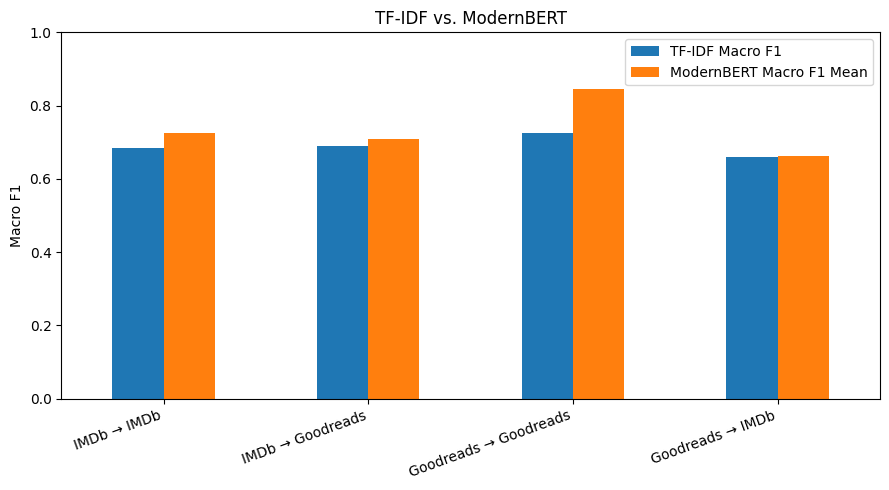

In [16]:
plot_df = overall[["TF-IDF Macro F1", "ModernBERT Macro F1 Mean"]]

ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("Macro F1")
ax.set_xlabel("")
ax.set_title("TF-IDF vs. ModernBERT")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 4. Cross-domain transfer

Transfer is compared on the **same target test set**:

- Goodreads target: Goodreads → Goodreads vs. IMDb → Goodreads
- IMDb target: IMDb → IMDb vs. Goodreads → IMDb

This prevents differences between the IMDb and Goodreads test sets from being mixed with the transfer effect.

In [17]:
def mb_mean(experiment):
    return float(macro_summary.loc[experiment, "Macro F1_mean"])

def tfidf_score(experiment):
    return float(tfidf_macro.loc[experiment, "TF-IDF Macro F1"])

transfer = pd.DataFrame([
    {
        "Target": "Goodreads",
        "TF-IDF in-domain": tfidf_score("Goodreads → Goodreads"),
        "TF-IDF cross-domain": tfidf_score("IMDb → Goodreads"),
        "ModernBERT in-domain": mb_mean("Goodreads → Goodreads"),
        "ModernBERT cross-domain": mb_mean("IMDb → Goodreads"),
    },
    {
        "Target": "IMDb",
        "TF-IDF in-domain": tfidf_score("IMDb → IMDb"),
        "TF-IDF cross-domain": tfidf_score("Goodreads → IMDb"),
        "ModernBERT in-domain": mb_mean("IMDb → IMDb"),
        "ModernBERT cross-domain": mb_mean("Goodreads → IMDb"),
    },
])

transfer["TF-IDF gap"] = (
    transfer["TF-IDF in-domain"] - transfer["TF-IDF cross-domain"]
)
transfer["ModernBERT gap"] = (
    transfer["ModernBERT in-domain"] - transfer["ModernBERT cross-domain"]
)

display(transfer.round(4))

,Target,TF-IDF in-domain,TF-IDF cross-domain,ModernBERT in-domain,ModernBERT cross-domain,TF-IDF gap,ModernBERT gap
0,Goodreads,0.7243,0.6907,0.8452,0.7101,0.0336,0.1351
1,IMDb,0.6844,0.6586,0.7249,0.6613,0.0259,0.0636


In [18]:
for _, row in transfer.iterrows():
    print(
        f'{row["Target"]} target | '
        f'TF-IDF gap: {row["TF-IDF gap"]:.4f} '
        f'({row["TF-IDF gap"]*100:.2f} pp) | '
        f'ModernBERT gap: {row["ModernBERT gap"]:.4f} '
        f'({row["ModernBERT gap"]*100:.2f} pp)'
    )

Goodreads target | TF-IDF gap: 0.0336 (3.36 pp) | ModernBERT gap: 0.1351 (13.51 pp)
IMDb target | TF-IDF gap: 0.0259 (2.59 pp) | ModernBERT gap: 0.0636 (6.36 pp)


## 5. 1,024-token truncation analysis

The models use the ModernBERT tokenizer with `MAX_LENGTH = 1024`. This section examines the consequences of that input limit.

The fine-grained analysis is possible for Goodreads because the original dataset contains sentence-level spoiler annotations. IMDb provides only review-level spoiler labels, so the exact location of spoiler evidence cannot be recovered for IMDb.

The extracted Goodreads file contains exactly the 20,000 sampled reviews used in the project. Upload `goodreads_20000_with_sentence_labels.jsonl` when prompted below. No model training or GPU is required.

In [19]:
# Colab upload for the extracted 20k Goodreads reviews.
# Skip this cell if GOODREADS_ANNOTATED_PATH is already set to an existing file.

from google.colab import files

uploaded = files.upload()

if "goodreads_20000_with_sentence_labels.jsonl" not in uploaded:
    raise FileNotFoundError(
        "Please upload goodreads_20000_with_sentence_labels.jsonl"
    )

GOODREADS_ANNOTATED_PATH = Path(
    "goodreads_20000_with_sentence_labels.jsonl"
)

print("Using:", GOODREADS_ANNOTATED_PATH)

Saving goodreads_20000_with_sentence_labels.jsonl to goodreads_20000_with_sentence_labels.jsonl
Using: goodreads_20000_with_sentence_labels.jsonl


In [20]:
# Tokenizer only; no model is loaded.
!pip -q install transformers

In [21]:
import json
from transformers import AutoTokenizer

CHECKPOINT = "answerdotai/ModernBERT-base"
MAX_LENGTH = 1024

tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT, use_fast=True)
special_tokens = tokenizer.num_special_tokens_to_add(pair=False)
content_limit = MAX_LENGTH - special_tokens

print("Maximum model sequence length:", MAX_LENGTH)
print("Special tokens:", special_tokens)
print("Maximum visible content tokens:", content_limit)

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Maximum model sequence length: 1024
Special tokens: 2
Maximum visible content tokens: 1022


### Goodreads spoiler-evidence visibility

For each review, the exact review text is reconstructed from `review_sentences` using the same single-space concatenation used during data preparation. Token offsets are computed on the complete reconstructed text without special tokens.

A spoiler sentence is classified as:

- **fully visible** if all overlapping content tokens are within the model-visible prefix,
- **crosses cutoff** if it has tokens both before and after the cutoff,
- **fully after cutoff** if all of its overlapping tokens occur after the cutoff.

At review level, we additionally identify positive reviews in which **all annotated spoiler evidence is after the cutoff**.

In [22]:
def reconstruct_with_spans(review_sentences):
    parts = []
    spans = []
    cursor = 0

    for i, sentence in enumerate(review_sentences):
        label = int(sentence[0])
        text = sentence[1]

        if i > 0:
            parts.append(" ")
            cursor += 1

        start = cursor
        parts.append(text)
        cursor += len(text)
        end = cursor

        spans.append((label, start, end))

    return "".join(parts), spans


records = []

with open(GOODREADS_ANNOTATED_PATH, "r", encoding="utf-8") as f:
    for line in f:
        review = json.loads(line)

        reconstructed, sentence_spans = reconstruct_with_spans(
            review["review_sentences"]
        )

        if reconstructed != review["review_text"]:
            raise ValueError(
                f'Reconstructed text mismatch for review_id={review.get("review_id")}'
            )

        encoded = tokenizer(
            reconstructed,
            add_special_tokens=False,
            return_offsets_mapping=True,
            truncation=False,
        )

        offsets = encoded["offset_mapping"]
        n_tokens = len(encoded["input_ids"])

        spoiler_statuses = []

        for label, char_start, char_end in sentence_spans:
            if label != 1:
                continue

            token_positions = [
                i
                for i, (tok_start, tok_end) in enumerate(offsets)
                if tok_end > char_start and tok_start < char_end
            ]

            if not token_positions:
                continue

            first_token = min(token_positions)
            last_token = max(token_positions)

            if first_token >= content_limit:
                status = "fully_after_cutoff"
            elif last_token >= content_limit:
                status = "crosses_cutoff"
            else:
                status = "fully_visible"

            spoiler_statuses.append(status)

        is_positive = bool(review["has_spoiler"])
        is_truncated = n_tokens > content_limit

        records.append({
            "sample_index": review["sample_index"],
            "book_id": review["book_id"],
            "review_id": review["review_id"],
            "has_spoiler": is_positive,
            "content_tokens": n_tokens,
            "is_truncated": is_truncated,
            "n_spoiler_sentences": len(spoiler_statuses),
            "n_spoiler_fully_visible": spoiler_statuses.count("fully_visible"),
            "n_spoiler_crosses_cutoff": spoiler_statuses.count("crosses_cutoff"),
            "n_spoiler_fully_after_cutoff": spoiler_statuses.count("fully_after_cutoff"),
        })

truncation = pd.DataFrame(records)

assert len(truncation) == 20_000
assert truncation["has_spoiler"].sum() == 10_000
assert (truncation.loc[truncation["has_spoiler"], "n_spoiler_sentences"] > 0).all()

truncation["any_spoiler_affected"] = (
    (truncation["n_spoiler_crosses_cutoff"] > 0)
    | (truncation["n_spoiler_fully_after_cutoff"] > 0)
)

truncation["all_spoiler_evidence_after_cutoff"] = (
    truncation["has_spoiler"]
    & (truncation["n_spoiler_sentences"] > 0)
    & (truncation["n_spoiler_fully_visible"] == 0)
    & (truncation["n_spoiler_crosses_cutoff"] == 0)
    & (truncation["n_spoiler_fully_after_cutoff"] > 0)
)

display(truncation.head())

,sample_index,book_id,review_id,has_spoiler,content_tokens,is_truncated,n_spoiler_sentences,n_spoiler_fully_visible,n_spoiler_crosses_cutoff,n_spoiler_fully_after_cutoff,any_spoiler_affected,all_spoiler_evidence_after_cutoff
0,0,9969571,846181b348be2a0866b068666bc1d22b,False,95,False,0,0,0,0,False,False
1,1,23006119,0e590c26bd1fc72a1c394b1b88ffdbab,True,282,False,1,1,0,0,False,False
2,2,32027348,4d3d30b38b71c66fa8a80faab68d3e56,True,216,False,5,5,0,0,False,False
3,3,11512712,0a266505ec509149e0938bebc9e906fd,True,393,False,4,4,0,0,False,False
4,4,20744085,cef45dd6c2aadb1eaf27d9f6d67819ec,False,86,False,0,0,0,0,False,False


In [23]:
positive = truncation[truncation["has_spoiler"]]

summary_truncation = pd.DataFrame({
    "Measure": [
        "All Goodreads reviews",
        "Reviews exceeding visible content limit",
        "Positive Goodreads reviews",
        "Positive reviews exceeding visible content limit",
        "Positive reviews with any spoiler sentence affected by cutoff",
        "Positive reviews with all annotated spoiler evidence after cutoff",
    ],
    "Count": [
        len(truncation),
        int(truncation["is_truncated"].sum()),
        len(positive),
        int(positive["is_truncated"].sum()),
        int(positive["any_spoiler_affected"].sum()),
        int(positive["all_spoiler_evidence_after_cutoff"].sum()),
    ],
})

summary_truncation["Percent of relevant population"] = [
    100.0,
    100 * truncation["is_truncated"].mean(),
    100.0,
    100 * positive["is_truncated"].mean(),
    100 * positive["any_spoiler_affected"].mean(),
    100 * positive["all_spoiler_evidence_after_cutoff"].mean(),
]

display(summary_truncation.round(2))

,Measure,Count,Percent of relevant population
0,All Goodreads reviews,20000,100.00
1,Reviews exceeding visible content limit,960,4.80
2,Positive Goodreads reviews,10000,100.00
3,Positive reviews exceeding visible content limit,751,7.51
4,Positive reviews with any spoiler sentence aff...,461,4.61
5,Positive reviews with all annotated spoiler ev...,91,0.91


In [24]:
sentence_totals = pd.Series({
    "Annotated spoiler sentences": int(positive["n_spoiler_sentences"].sum()),
    "Fully visible": int(positive["n_spoiler_fully_visible"].sum()),
    "Crosses cutoff": int(positive["n_spoiler_crosses_cutoff"].sum()),
    "Fully after cutoff": int(positive["n_spoiler_fully_after_cutoff"].sum()),
})

display(sentence_totals.to_frame("Count"))

,Count
Annotated spoiler sentences,61676
Fully visible,56447
Crosses cutoff,269
Fully after cutoff,4960


In [25]:
# Save a compact derived file; the large extracted JSONL does not need to be
# committed to the repository.
TRUNCATION_OUTPUT = RESULTS_DIR / "goodreads_truncation_analysis.csv"
truncation.to_csv(TRUNCATION_OUTPUT, index=False)

print("Saved:", TRUNCATION_OUTPUT)

Saved: results/goodreads_truncation_analysis.csv


## 6. Detailed cross-domain prediction analysis — seed 42

The following analyses use the seed-42 ModernBERT models as representative model instances. They are prediction-level exploratory analyses and are kept separate from the three-seed aggregate main results.

### Confidence analysis

The maximum softmax score of the predicted class is used as a prediction-confidence score. It should not be interpreted as a calibrated probability of correctness.

In [26]:
display(confidence)

,Experiment,Mean Confidence,Correct Confidence,Incorrect Confidence,Errors,High Confidence Errors,High Confidence Error Share
0,IMDb → Goodreads,0.862566,0.887443,0.794900,829,271,0.326900
1,Goodreads → IMDb,0.907735,0.923035,0.877565,1099,675,0.614195


### Review-length analysis

Review length was measured before truncation. The existing analysis reports class distribution and cross-domain performance across five length groups.

In [27]:
display(length_results)

,Length,N,Accuracy,Recall,Macro F1,Experiment
0,≤128,978,0.830266,0.429245,0.709877,IMDb → Goodreads
1,129–256,681,0.696035,0.782609,0.683019,IMDb → Goodreads
2,257–512,782,0.662404,0.897177,0.563664,IMDb → Goodreads
3,513–1024,517,0.690522,0.956395,0.531830,IMDb → Goodreads
4,>1024,126,0.746032,0.978947,0.456017,IMDb → Goodreads
5,≤128,322,0.760870,0.307692,0.574826,Goodreads → IMDb
6,129–256,1246,0.659711,0.437008,0.625218,Goodreads → IMDb
7,257–512,978,0.620654,0.583916,0.619173,Goodreads → IMDb
8,513–1024,584,0.669521,0.718421,0.644476,Goodreads → IMDb
9,>1024,136,0.750000,0.854369,0.644854,Goodreads → IMDb


In [28]:
print("Length-analysis columns:", length_results.columns.tolist())

Length-analysis columns: ['Length', 'N', 'Accuracy', 'Recall', 'Macro F1', 'Experiment']


### Qualitative cross-domain error sample

The qualitative sample contains 10 false positives and 10 false negatives for each cross-domain direction (40 examples in total), sampled with seed 42. This small sample is exploratory rather than representative.

In [29]:
print("Qualitative error examples:", len(error_samples))
display(error_samples)

Qualitative error examples: 40


,review_text,is_spoiler,item_id,y_true,y_pred,error_type,direction
0,The story follows Annalisa Townsend who is sai...,False,493051,0,1,FP,IMDb → Goodreads
1,Anya Whitson is a cold woman. She has never lo...,False,6668467,0,1,FP,IMDb → Goodreads
2,3.75 stars I received an e-ARC copy of To Have...,False,27271035,0,1,FP,IMDb → Goodreads
3,"Ramblings. Yes, I'm still in my ""prolonging Th...",False,6538757,0,1,FP,IMDb → Goodreads
4,"Okay, so I may have over hyped myself with thi...",False,16006196,0,1,FP,IMDb → Goodreads
5,This is the story of Lila whom started her lif...,False,20575411,0,1,FP,IMDb → Goodreads
6,"After reading the second novella, I thought pe...",False,13419891,0,1,FP,IMDb → Goodreads
7,Mmm I wasn't a super big fan of this one. The ...,False,9749711,0,1,FP,IMDb → Goodreads
8,I DNF at 26% because the plot was just too dra...,False,28418764,0,1,FP,IMDb → Goodreads
9,I stumbled upon Whitney's When You Were Here a...,False,6882274,0,1,FP,IMDb → Goodreads


## 7. Final key results

This section derives the main numbers directly from the loaded result files instead of hard-coding them.

In [30]:
print("MODERNBERT — MACRO F1 (mean ± sample SD)")
for exp in experiment_order:
    mean = macro_summary.loc[exp, "Macro F1_mean"]
    std = macro_summary.loc[exp, "Macro F1_std"]
    print(f"{exp}: {mean:.4f} ± {std:.4f}")

print("\nTARGET-CONTROLLED TRANSFER GAPS")
for _, row in transfer.iterrows():
    print(
        f'{row["Target"]}: '
        f'ModernBERT {row["ModernBERT gap"]:.4f} '
        f'({row["ModernBERT gap"]*100:.2f} pp), '
        f'TF-IDF {row["TF-IDF gap"]:.4f} '
        f'({row["TF-IDF gap"]*100:.2f} pp)'
    )

print("\nMODERNBERT MINUS TF-IDF")
for exp, row in overall.iterrows():
    print(f'{exp}: {row["ModernBERT - TF-IDF"]:+.4f}')

MODERNBERT — MACRO F1 (mean ± sample SD)
IMDb → IMDb: 0.7249 ± 0.0057
IMDb → Goodreads: 0.7101 ± 0.0167
Goodreads → Goodreads: 0.8452 ± 0.0066
Goodreads → IMDb: 0.6613 ± 0.0030

TARGET-CONTROLLED TRANSFER GAPS
Goodreads: ModernBERT 0.1351 (13.51 pp), TF-IDF 0.0336 (3.36 pp)
IMDb: ModernBERT 0.0636 (6.36 pp), TF-IDF 0.0259 (2.59 pp)

MODERNBERT MINUS TF-IDF
IMDb → IMDb: +0.0404
IMDb → Goodreads: +0.0193
Goodreads → Goodreads: +0.1209
Goodreads → IMDb: +0.0027


In [31]:
print("GOODREADS TRUNCATION")
print(
    f'Reviews above the visible content limit: '
    f'{truncation["is_truncated"].sum():,}/{len(truncation):,} '
    f'({100 * truncation["is_truncated"].mean():.2f}%)'
)
print(
    f'Positive reviews above the visible content limit: '
    f'{positive["is_truncated"].sum():,}/{len(positive):,} '
    f'({100 * positive["is_truncated"].mean():.2f}%)'
)
print(
    f'Positive reviews with any annotated spoiler sentence affected: '
    f'{positive["any_spoiler_affected"].sum():,}/{len(positive):,} '
    f'({100 * positive["any_spoiler_affected"].mean():.2f}%)'
)
print(
    f'Positive reviews with all annotated spoiler evidence after cutoff: '
    f'{positive["all_spoiler_evidence_after_cutoff"].sum():,}/{len(positive):,} '
    f'({100 * positive["all_spoiler_evidence_after_cutoff"].mean():.2f}%)'
)

GOODREADS TRUNCATION
Reviews above the visible content limit: 960/20,000 (4.80%)
Positive reviews above the visible content limit: 751/10,000 (7.51%)
Positive reviews with any annotated spoiler sentence affected: 461/10,000 (4.61%)
Positive reviews with all annotated spoiler evidence after cutoff: 91/10,000 (0.91%)


## Interpretation notes

The main classification results should be interpreted from the three-seed ModernBERT aggregates. Transfer effects are always compared on identical target test sets.

The seed-42 confidence, length, and qualitative error analyses provide additional exploratory information about prediction behavior but are not estimates of variation across fine-tuning seeds.

The Goodreads truncation analysis is independent of the fine-tuning seed and examines the fixed preprocessing decision to limit model inputs to 1,024 tokens. Because IMDb contains only review-level spoiler labels, equivalent sentence-level spoiler-evidence localization is not available for IMDb.

Observed differences between IMDb and Goodreads should be described as **cross-dataset transfer effects**. Narrative domain, platform, and annotation scheme change simultaneously, so the experiment does not isolate media domain as a causal factor.